## Invoice Risk Classification

**Objective:** Build a classification model that identifies vendor invoices requiring manual review based on transaction characteristics such as cost, freight charges, and procurement patterns.

- Reviewing every invoice manually can be resource-intensive and difficult to maintain as transaction volumes increase.
- Unusual cost patterns, elevated freight charges, or irregular purchasing behavior may indicate potential errors, inconsistencies, or financial risks.
- Automated invoice classification helps prioritize high-risk transactions for further investigation while enabling routine invoices to be processed more efficiently.

## Importing Libraries

In [3]:
import sqlite3
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from pathlib import Path
from scipy.stats import ttest_ind
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import make_scorer, f1_score
from sklearn.model_selection import GridSearchCV

## Data Analysis

In [5]:
# Get the project's root directory (one level above the current working directory)
project_root = Path.cwd().parent

# Construct the path to the SQLite database
db_path = project_root / "data" / "inventory.db"

# Establish a connection to the SQLite database
conn = sqlite3.connect(db_path)

In [6]:
df = pd.read_sql_query("""
-- Create a temporary table that aggregates purchase-level information
WITH purchase_agg AS (
    SELECT
        p.PONumber,

        -- Count the number of unique brands in each purchase order
        COUNT(DISTINCT p.Brand) AS total_brands,

        -- Calculate the total quantity purchased for each PO
        SUM(p.Quantity) AS total_item_quantity,

        -- Calculate the total purchase value for each PO
        SUM(p.Dollars) AS total_item_dollars,

        -- Compute the average receiving delay (in days)
        AVG(julianday(p.ReceivingDate) - julianday(p.PODate)) AS avg_receiving_delay

    FROM purchases p
    GROUP BY p.PONumber
)

SELECT

    -- Purchase Order identifier
    vi.PONumber,

    -- Invoice-level transaction details
    vi.Quantity AS invoice_quantity,
    vi.Dollars AS invoice_dollars,
    vi.Freight,

    -- Number of days between PO creation and invoice generation
    (julianday(vi.InvoiceDate) - julianday(vi.PODate)) AS days_po_to_invoice,

    -- Number of days taken to pay the invoice
    (julianday(vi.PayDate) - julianday(vi.InvoiceDate)) AS days_to_pay,

    -- Aggregated purchase-level features
    pa.total_brands,
    pa.total_item_quantity,
    pa.total_item_dollars,
    pa.avg_receiving_delay

FROM vendor_invoice vi

-- Join invoice data with aggregated purchase data using Purchase Order Number
LEFT JOIN purchase_agg pa
    ON vi.PONumber = pa.PONumber

""", conn)

| Column | Description |
|--------|-------------|
| **PONumber** | Unique identifier for each purchase order. |
| **invoice_quantity** | Total quantity recorded on the vendor invoice. |
| **invoice_dollars** | Total amount billed on the vendor invoice. |
| **Freight** | Shipping or transportation cost associated with the invoice. |
| **days_po_to_invoice** | Number of days between the purchase order date and the invoice date. |
| **days_to_pay** | Number of days taken to pay the invoice after it was issued. |
| **total_brands** | Number of unique brands included in the purchase order. |
| **total_item_quantity** | Total quantity of all items in the purchase order. |
| **total_item_dollars** | Total monetary value of all items in the purchase order. |
| **avg_receiving_delay** | Average number of days taken to receive items after the purchase order was placed. |

In [8]:
df.head()

,PONumber,invoice_quantity,invoice_dollars,Freight,days_po_to_invoice,days_to_pay,total_brands,total_item_quantity,total_item_dollars,avg_receiving_delay
0,8124,6,214.26,3.47,14.0,43.0,1,6,214.26,12.000000
1,8137,15,140.55,8.57,16.0,45.0,2,15,140.55,10.333333
2,8169,5,106.60,4.61,16.0,38.0,1,5,106.60,9.000000
3,8106,10100,137483.78,2935.20,23.0,24.0,81,10100,137483.78,12.614130
4,8170,1935,15527.25,429.20,14.0,36.0,29,1935,15527.25,8.752809


In [9]:
df.isnull().sum()

PONumber               0
invoice_quantity       0
invoice_dollars        0
Freight                0
days_po_to_invoice     0
days_to_pay            0
total_brands           0
total_item_quantity    0
total_item_dollars     0
avg_receiving_delay    0
dtype: int64

In [10]:
def create_invoice_risk_label(row):

    # Invoice total mismatch with item-level total
    if (abs(row["invoice_dollars"] - row["total_item_dollars"]) > 5):
        return 1

    # Abnormally high receiving delay
    if row["avg_receiving_delay"] > 10:
        return 1
        
    return 0
df["flag_invoice"] = df.apply(create_invoice_risk_label, axis=1)
df["flag_invoice"].value_counts()

flag_invoice
0    3693
1    1850
Name: count, dtype: int64

In [11]:
# Create a feature representing the invoice amount mismatch
df["amount_difference"] = (

    df["invoice_dollars"] - df["total_item_dollars"]

).abs()

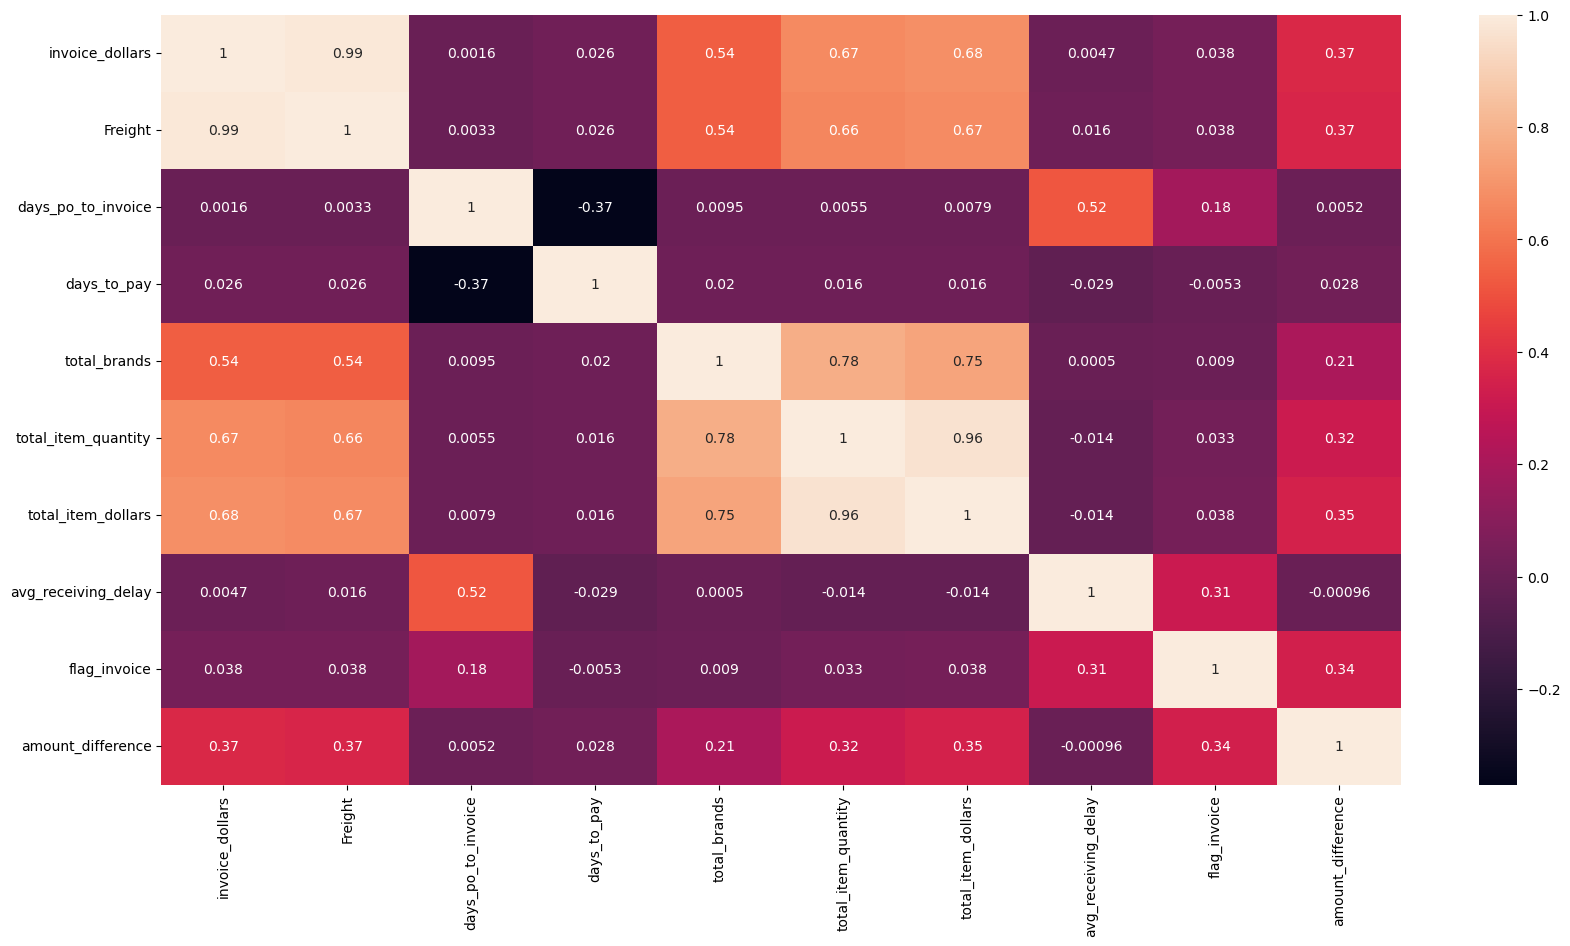

In [12]:
plt.figure(figsize=(20,10))
sns.heatmap(df.iloc[:,2:].corr(),annot =True)
plt.show()

## Statistical Significance Testing

Before building the classification model, a statistical analysis was performed to determine whether the numerical features differ significantly between **flagged** and **normal** invoices.

### What is a t-test?

A **t-test** is a statistical test used to compare the **means of two independent groups** and determine whether the observed difference is statistically significant or simply due to random variation.

In this project, the two groups are:

- **Flagged invoices** (high risk)
- **Normal invoices** (low risk)

For each numerical feature (e.g., Freight, Invoice Amount, Receiving Delay), the t-test evaluates whether the average value differs significantly between these two groups.

### What is a p-value?

The **p-value** measures the probability that the observed difference between the two groups occurred by chance.

The significance level used in this project is **0.05 (5%)**.

- **p-value < 0.05** → The difference is statistically significant.
- **p-value ≥ 0.05** → The difference is not statistically significant.

### Why is this analysis important?

Performing a t-test helps identify which features meaningfully distinguish flagged invoices from normal invoices. Features with statistically significant differences are more likely to be useful predictors for the machine learning model and provide valuable business insights into the factors associated with invoice risk.

In [14]:

flagged = df[df["flag_invoice"] == 1]
normal = df[df["flag_invoice"] == 0]

metrics = ['invoice_quantity', 'invoice_dollars', 'Freight',
       'days_po_to_invoice', 'days_to_pay', 'total_brands',
       'total_item_quantity', 'total_item_dollars', 'avg_receiving_delay', 'amount_difference']

results = []
significant_features = []
non_significant_features = []

for metric in metrics:
    flagged_mean = flagged[metric].mean()
    normal_mean = normal[metric].mean()

    t_stat, p_value = ttest_ind(
        flagged[metric].dropna(),
        normal[metric].dropna(),
        equal_var=False
    )
    
    if p_value < 0.05:
        significant_features.append(metric)
        results.append({
        "metric": metric,
        "flagged_mean": flagged_mean.round(2),
        "normal_mean": normal_mean.round(2),
        "p_value": p_value.round(3)
    })
    else:
        non_significant_features.append(metric)

In [15]:
non_significant_features

['days_to_pay', 'total_brands']

In [16]:
pd.DataFrame(results)

,metric,flagged_mean,normal_mean,p_value
0,invoice_quantity,6728.28,5723.55,0.021
1,invoice_dollars,65600.61,54302.64,0.008
2,Freight,334.02,276.89,0.008
3,days_po_to_invoice,17.23,16.02,0.000
4,total_item_quantity,6728.28,5723.55,0.021
5,total_item_dollars,65600.61,54302.64,0.008
6,avg_receiving_delay,8.47,7.27,0.000
7,amount_difference,78100.16,0.00,0.000


### Observations:

The amount_difference feature shows the largest difference between flagged and normal invoices, with flagged invoices exhibiting a substantially higher average mismatch between invoice and purchase order amounts. The extremely small p-value confirms that this feature strongly distinguishes the two groups. This result is expected because amount_difference is one of the business rules used to generate the invoice risk labels.

The statistical analysis shows that flagged invoices consistently have higher average values than normal invoices, and these differences are statistically significant. This indicates that the observed differences are unlikely to have occurred by chance and support the business rules used to identify invoices requiring manual review.

The results suggest that flagged invoices generally involve larger purchase volumes, higher invoice amounts, increased freight costs, greater order complexity, and longer procurement and payment cycles. These characteristics indicate that invoices selected for manual review are typically associated with higher financial exposure and operational complexity rather than isolated pricing discrepancies.

Furthermore, the very small p-values obtained from the t-tests provide strong statistical evidence that these features effectively distinguish flagged invoices from normal invoices. Consequently, these variables are valuable predictors for invoice risk classification and support the development of a reliable machine learning model.

## Machine Learning Modeling

In [19]:
def evaluate_model(model, X_test, y_test, model_name):
    preds = model.predict(X_test)
    
    accuracy = accuracy_score(y_test, preds)
    report = classification_report(y_test, preds)
    
    print(f"\n{model_name} Performance:")
    print(f"Accuracy  : {accuracy:.2f}")
    print(f"Classification Report : \n{report}")

In [20]:
X = df[['invoice_quantity','invoice_dollars','Freight','total_brands','total_item_quantity','days_po_to_invoice','total_item_dollars', 'amount_difference']]
y = df['flag_invoice']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

model1 = LogisticRegression(random_state=42)
model1.fit(X_train_scaled, y_train)

model2 = DecisionTreeClassifier(random_state = 42)
model2.fit(X_train_scaled, y_train)

model3 = RandomForestClassifier(random_state = 42)
model3.fit(X_train_scaled, y_train)

evaluate_model(model1, X_test_scaled, y_test, 'Logistic Regression')
evaluate_model(model2, X_test_scaled, y_test, 'Decision Tree Classifier')
evaluate_model(model3, X_test_scaled, y_test, 'Random Forest Classifier')


Logistic Regression Performance:
Accuracy  : 0.83
Classification Report : 
              precision    recall  f1-score   support

           0       0.79      1.00      0.88       725
           1       1.00      0.49      0.66       384

    accuracy                           0.83      1109
   macro avg       0.89      0.75      0.77      1109
weighted avg       0.86      0.83      0.81      1109


Decision Tree Classifier Performance:
Accuracy  : 0.86
Classification Report : 
              precision    recall  f1-score   support

           0       0.89      0.90      0.89       725
           1       0.80      0.78      0.79       384

    accuracy                           0.86      1109
   macro avg       0.84      0.84      0.84      1109
weighted avg       0.86      0.86      0.86      1109


Random Forest Classifier Performance:
Accuracy  : 0.91
Classification Report : 
              precision    recall  f1-score   support

           0       0.89      0.98      0.93       725

In [21]:
feature_importance = pd.DataFrame({
    "feature": X_train.columns,
    "importance": model3.feature_importances_
}).sort_values(by="importance", ascending=False)

feature_importance

,feature,importance
7,amount_difference,0.542169
6,total_item_dollars,0.078662
2,Freight,0.073906
5,days_po_to_invoice,0.071236
4,total_item_quantity,0.068529
1,invoice_dollars,0.065978
0,invoice_quantity,0.055168
3,total_brands,0.044354


## Hyperparameter Tuning

In [71]:
X = df[['invoice_quantity','invoice_dollars','Freight','total_item_quantity','total_item_dollars', 'amount_difference']]
y = df['flag_invoice']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [73]:
rf = RandomForestClassifier(
    random_state=42,
    n_jobs=-1
)

param_grid = {
    "n_estimators": [100,200, 300],
    "max_depth": [None, 4, 5, 6],
    "min_samples_split": [2, 3, 5],
    "min_samples_leaf": [1, 2, 5],
    "criterion":['gini','entropy']
}
scorer = make_scorer(f1_score)
grid_search = GridSearchCV(
    estimator=rf,
    param_grid=param_grid,
    scoring=scorer,
    cv=5,
    verbose=2,
    n_jobs=-1
)

grid_search.fit(X_train_scaled, y_train)
evaluate_model(grid_search, X_test_scaled, y_test, 'Random Forest Classifier')

Fitting 5 folds for each of 216 candidates, totalling 1080 fits

Random Forest Classifier Performance:
Accuracy  : 0.91
Classification Report : 
              precision    recall  f1-score   support

           0       0.88      1.00      0.94       725
           1       1.00      0.74      0.85       384

    accuracy                           0.91      1109
   macro avg       0.94      0.87      0.89      1109
weighted avg       0.92      0.91      0.91      1109



In [82]:
# Features used for prediction

X = df[

    [

        "invoice_quantity",

        "invoice_dollars",

        "Freight",

        "total_brands",

        "total_item_quantity",

        "days_po_to_invoice",

        "total_item_dollars",

        "amount_difference"

    ]

]

# Predict for all invoices

df["Predicted_Risk"] = model3.predict(X)

# Count predictions

df["Predicted_Risk"].value_counts()

/opt/anaconda3/lib/python3.12/site-packages/sklearn/base.py:486: UserWarning: X has feature names, but RandomForestClassifier was fitted without feature names
  warnings.warn(


Predicted_Risk
1    5543
Name: count, dtype: int64